In [ ]:
from collections import defaultdict
from pathlib import Path

import gymnasium as gym
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


## 1. Environment Setup

In [ ]:
BASELINE_HEIGHT = 15
BASELINE_WIDTH = 20
BASELINE_PIPE_GAP = 4

In [105]:
TRAIN_AGENT = True
SAVE_AGENT = True

BASE_PATH = Path("../models")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)


In [106]:
env = gym.make(
    "TextFlappyBird-v0",
    height=BASELINE_HEIGHT,
    width=BASELINE_WIDTH,
    pipe_gap=BASELINE_PIPE_GAP,
)

obs, info = env.reset()
print(f"Observation: {obs}")
print(f"Action space: {env.action_space}")  # Discrete(2)

Observation: (13, -3)
Action space: Discrete(2)


## 2. Monte Carlo Agent

**Monte Carlo (MC) control** learns a Q-function purely from complete episode trajectories — no bootstrapping, no model. After each episode ends we walk backwards through the trajectory, compute the discounted return $G_t$, and update $Q(s,a)$ with the sample mean (first-visit). Policy improvement is implicit: we always act $\varepsilon$-greedy with respect to the current Q.

**State space:** `(x_dist, y_dist)` — distance to the next pipe horizontally and vertically. This gives a small, discrete state space that fits comfortably in a table.

**Epsilon decay** drives the exploration–exploitation trade-off:
- *Linear*: $\varepsilon \leftarrow \max(\varepsilon_{\min},\; \varepsilon - d)$
- *Exponential*: $\varepsilon \leftarrow \max(\varepsilon_{\min},\; \varepsilon \cdot (1-d))$

In [ ]:
class MCAgent:
    """The Q-table is sized exactly to the reachable observation space:
      x_dist ∈ [0, x_max]  where  x_max = width  - int(width*0.3)  - 1
      y_dist ∈ [-y_max, y_max]  where  y_max = height - 1 - pipe_gap//2 - 1

    Index mapping: Q[x_dist,  y_dist + y_max,  action]
    """

    def __init__(
        self,
        height: int,
        width: int,
        pipe_gap: int,
        gamma: float = 0.99,
        epsilon: float = 1.0,
        epsilon_min: float = 0.01,
        epsilon_decay: float = 5e-4,
        decay_mode: str = "linear",
        seed: int = 42,
    ):
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.decay_mode = decay_mode

        # Exact observation bounds for TextFlappyBird-v0
        self._x_max = width - int(width * 0.3) - 1  # max x_dist
        self._y_max = height - 1 - pipe_gap // 2 - 1  # max |y_dist|
        self._y_offset = self._y_max  # shift: y_idx = y + y_max

        # Q-table covers the full reachable state space exactly
        self.Q = np.zeros((self._x_max + 1, 2 * self._y_max + 1, 2))
        self._returns: dict = defaultdict(list)
        self._rng = np.random.default_rng(seed)

    def _idx(self, state):
        x = int(np.clip(state[0], 0, self._x_max))
        y = int(np.clip(state[1] + self._y_offset, 0, 2 * self._y_max))
        return (x, y)

    def act(self, state) -> int:
        if self._rng.random() < self.epsilon:
            return int(self._rng.integers(2))
        return int(np.argmax(self.Q[self._idx(state)]))

    def update(self, trajectory: list) -> None:
        G = 0.0
        visited: set = set()
        for state, action, reward in reversed(trajectory):
            G = reward + self.gamma * G
            idx = self._idx(state)
            key = (idx, action)
            if key not in visited:
                visited.add(key)
                self._returns[key].append(G)
                self.Q[idx][action] = np.mean(self._returns[key])

    def decay_epsilon(self) -> None:
        if self.decay_mode == "linear":
            self.epsilon = max(self.epsilon_min, self.epsilon - self.epsilon_decay)
        else:
            self.epsilon = max(self.epsilon_min, self.epsilon * (1.0 - self.epsilon_decay))

    def save(self, path: Path) -> None:
        path.parent.mkdir(parents=True, exist_ok=True)
        np.save(path, self.Q)

    def load(self, path) -> None:
        self.Q = np.load(path)


In [ ]:
def plot_value_function(agent, title="", save_path=None):
    Q = agent.Q  # (x_max+1, 2*y_max+1, 2)
    V = np.max(Q, axis=2)  # (x_max+1, 2*y_max+1)
    policy = np.argmax(Q, axis=2)

    y_max = agent._y_max

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # V(s) — transpose so x_dist is x-axis, y_dist is y-axis
    # origin='upper': row 0 (top) = y_idx 0 = y_dist -y_max (bird above gap)
    im = ax1.imshow(V.T, cmap="RdYlGn", aspect="auto", origin="upper")
    ax1.set_xlabel("x_dist  (horizontal distance to next pipe)")

    step = max(1, y_max // 4)
    ytick_idx = np.arange(0, 2 * y_max + 1, step)
    ax1.set_yticks(ytick_idx)
    ax1.set_yticklabels(ytick_idx - y_max)  # convert index → y_dist
    ax1.set_ylabel("y_dist  (− = bird above gap  ·  + = bird below gap)")
    ax1.set_title(f"V(s) = max_a Q(s,a){' — ' + title if title else ''}")
    plt.colorbar(im, ax=ax1)

    cmap2 = mcolors.ListedColormap(["#d9534f", "#5cb85c"])
    ax2.imshow(policy.T, cmap=cmap2, aspect="auto", origin="upper", vmin=0, vmax=1)
    ax2.set_xlabel("x_dist")
    ax2.set_yticks(ytick_idx)
    ax2.set_yticklabels(ytick_idx - y_max)
    ax2.set_ylabel("y_dist")
    ax2.set_title("Greedy policy  (red = no flap · green = flap)")

    for ax in (ax1, ax2):
        ax.axhline(y_max, color="white", linewidth=1.2, linestyle="--", alpha=0.6)

    if title:
        plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


### Training Loop


In [109]:
def run_episode(env, agent: "MCAgent", max_steps: int):
    state, _ = env.reset()
    trajectory = []
    total_reward = 0.0

    for _ in range(max_steps):
        action = agent.act(state)
        next_state, reward, done, _, _ = env.step(action)
        trajectory.append((state, action, reward))
        total_reward += reward
        state = next_state
        if done:
            break

    agent.update(trajectory)
    agent.decay_epsilon()
    return total_reward, len(trajectory)


def train(agent, env, episodes, max_steps, log_every):
    rewards, epsilons = [], []

    for ep in tqdm(range(episodes), desc="Training"):
        r, _ = run_episode(env, agent, max_steps)
        rewards.append(r)
        epsilons.append(agent.epsilon)

        if ep > 0 and ep % log_every == 0:
            avg_r = np.mean(rewards[-log_every:])
            print(
                f"Episode {ep:>7d} | Avg reward (last {log_every}): {avg_r:7.2f} | Epsilon {agent.epsilon:.5f}",
            )

    return rewards, epsilons


In [110]:
# AGENT
GAMMA = 0.9
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.0005  # per-episode decay amount
DECAY_MODE = "linear"  # "linear" | "exp"

# Training
N_EPISODES = 5_000
LOG_EVERY = 1_000
MAX_STEPS = 3_000
SEED = 42
SAVE_PATH = "MC_agent.npy"
LOAD_PATH = "MC_agent.npy"


In [111]:
agent = MCAgent(
    height=BASELINE_HEIGHT,
    width=BASELINE_WIDTH,
    pipe_gap=BASELINE_PIPE_GAP,
    gamma=GAMMA,
    epsilon=EPSILON_START,
    epsilon_min=EPSILON_MIN,
    epsilon_decay=EPSILON_DECAY,
    decay_mode=DECAY_MODE,
    seed=SEED,
)

rewards, epsilons = [], []
if TRAIN_AGENT:
    rewards, epsilons = train(agent, env, N_EPISODES, MAX_STEPS, LOG_EVERY)
    if SAVE_AGENT:
        path = BASE_PATH / SAVE_PATH
        agent.save(path)
else:
    path = BASE_PATH / LOAD_PATH
    agent.load(path)


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Training:  22%|██▏       | 1106/5000 [00:01<00:05, 708.38it/s]

Episode    1000 | Avg reward (last 1000):   15.99 | Epsilon 0.49950


Training:  40%|████      | 2002/5000 [00:07<01:43, 29.00it/s] 

Episode    2000 | Avg reward (last 1000):  113.62 | Epsilon 0.01000


Training:  60%|██████    | 3003/5000 [00:54<01:19, 25.27it/s]

Episode    3000 | Avg reward (last 1000):  961.85 | Epsilon 0.01000


Training:  80%|████████  | 4002/5000 [01:49<01:19, 12.60it/s]

Episode    4000 | Avg reward (last 1000): 1017.84 | Epsilon 0.01000


Training: 100%|██████████| 5000/5000 [02:50<00:00, 29.27it/s]


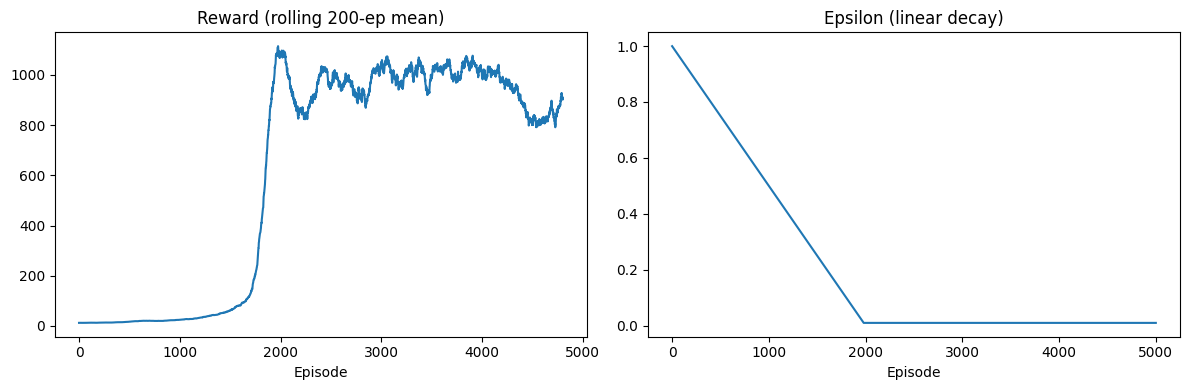

In [112]:
if rewards:
    window = 200
    smoothed = np.convolve(rewards, np.ones(window) / window, mode="valid")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(smoothed)
    ax1.set_title(f"Reward (rolling {window}-ep mean)")
    ax1.set_xlabel("Episode")

    ax2.plot(epsilons)
    ax2.set_title(f"Epsilon ({DECAY_MODE} decay)")
    ax2.set_xlabel("Episode")

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "mc_training_curve.png", bbox_inches="tight")
    plt.show()

### Evaluation

In [ ]:
def evaluate(env, agent, n_episodes, max_steps):
    old_eps = agent.epsilon
    agent.epsilon = 0.0
    total_rewards = []
    for _ in tqdm(range(n_episodes), desc="Evaluating", leave=False):
        obs, _ = env.reset()
        state = obs
        total_reward = 0.0
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = agent.act(state)
            obs, reward, done, _, _ = env.step(action)
            state = obs
            total_reward += reward
            steps += 1
        total_rewards.append(total_reward)
    agent.epsilon = old_eps
    return total_rewards


In [114]:
total_rewards = evaluate(env, agent, n_episodes=100, max_steps=5000)
print("Greedy evaluation over 100 episodes:")
print(f"Mean reward: {np.mean(total_rewards):.2f}")

Greedy evaluation over 100 episodes:
Mean reward: 5000.00


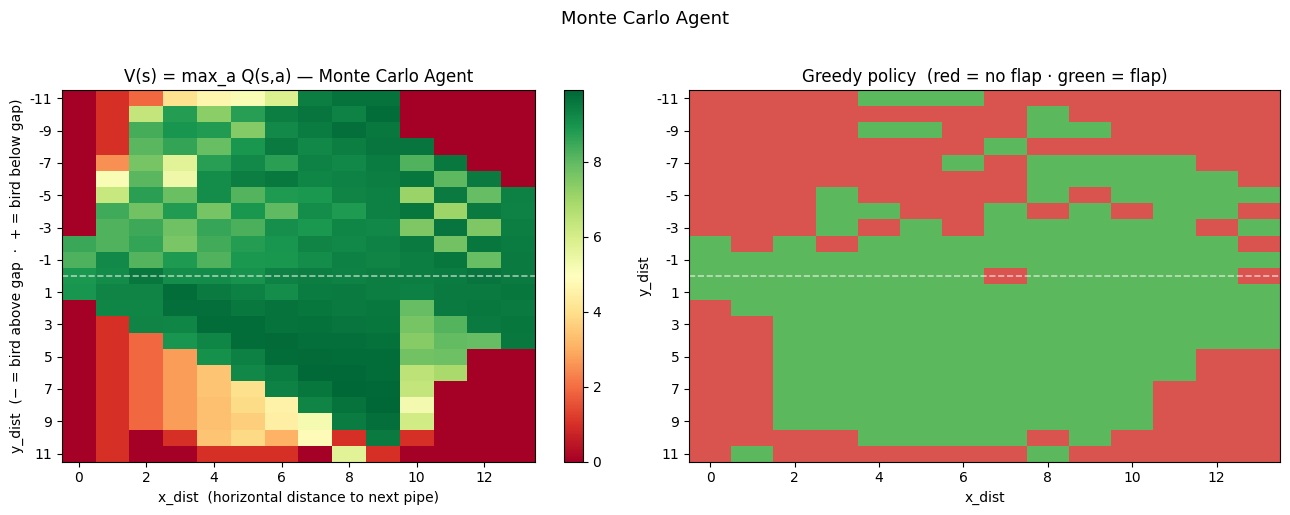

In [115]:
plot_value_function(agent, "Monte Carlo Agent", save_path=FIGURES_DIR / "mc_value_function.png")


### Hyperparameter Grid Search


In [ ]:
import itertools
import pickle

RETRAIN_MC_SWEEP = True
MC_SWEEP_PATH = BASE_PATH / "mc_sweep_results.pkl"

# Grid — same explore_frac parameterisation as Sarsa sweep for coherence:
# sweep_decay = (eps_start - eps_min) / (frac * N_SWEEP_EPISODES)
# retrain_decay = (eps_start - eps_min) / (frac * N_EPISODES)
_gammas = [0.85, 0.90, 0.95]
_explore_fracs_mc = [0.3, 0.6, 0.9]  # fraction of training spent exploring
_decay_modes = ["linear", "exp"]

N_SWEEP_EPISODES = 1_000
N_SWEEP_EVAL = 50

if RETRAIN_MC_SWEEP or not MC_SWEEP_PATH.exists():
    sweep_env = gym.make(
        "TextFlappyBird-v0",
        height=BASELINE_HEIGHT,
        width=BASELINE_WIDTH,
        pipe_gap=BASELINE_PIPE_GAP,
    )
    mc_sweep_results = []

    combos = list(itertools.product(_gammas, _explore_fracs_mc, _decay_modes))
    for gamma, frac, mode in tqdm(combos, desc="MC sweep"):
        sweep_decay = (EPSILON_START - EPSILON_MIN) / (frac * N_SWEEP_EPISODES)
        ag = MCAgent(
            height=BASELINE_HEIGHT,
            width=BASELINE_WIDTH,
            pipe_gap=BASELINE_PIPE_GAP,
            gamma=gamma,
            epsilon=EPSILON_START,
            epsilon_min=EPSILON_MIN,
            epsilon_decay=sweep_decay,
            decay_mode=mode,
            seed=SEED,
        )
        curve, _ = train(ag, sweep_env, N_SWEEP_EPISODES, MAX_STEPS, log_every=N_SWEEP_EPISODES + 1)
        eval_rewards = evaluate(sweep_env, ag, N_SWEEP_EVAL, MAX_STEPS)
        mc_sweep_results.append(
            {
                "gamma": gamma,
                "explore_frac": frac,
                "mode": mode,
                "mean_eval": float(np.mean(eval_rewards)),
                "curve": curve,
            },
        )

    sweep_env.close()
    MC_SWEEP_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(MC_SWEEP_PATH, "wb") as f:
        pickle.dump(mc_sweep_results, f)
    print(f"Saved MC sweep results to {MC_SWEEP_PATH}")
else:
    with open(MC_SWEEP_PATH, "rb") as f:
        mc_sweep_results = pickle.load(f)
    print(f"Loaded MC sweep results from {MC_SWEEP_PATH}")

best_mc = max(mc_sweep_results, key=lambda x: x["mean_eval"])
print(
    f"\nBest MC config: gamma={best_mc['gamma']}, explore_frac={best_mc['explore_frac']}, "
    f"mode={best_mc['mode']}  →  mean_eval={best_mc['mean_eval']:.2f}",
)


MC sweep: 100%|██████████| 18/18 [04:04<00:00, 13.58s/it]


Saved MC sweep results to ../models/mc_sweep_results.pkl

Best MC config: gamma=0.85, explore_frac=0.3, mode=exp  →  mean_eval=3000.00


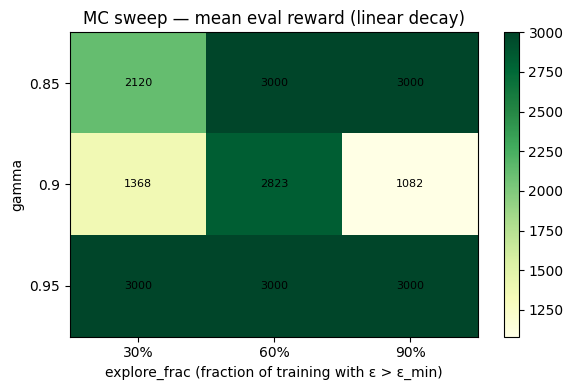

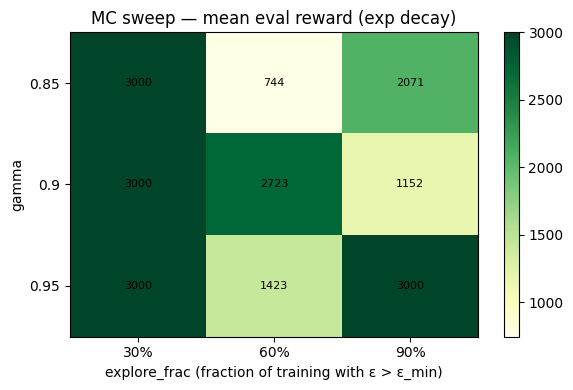

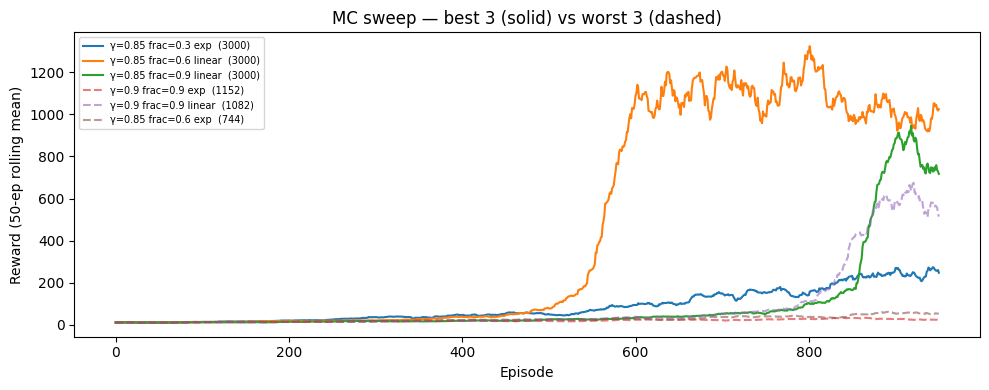

In [117]:
for mode in _decay_modes:
    sub = [r for r in mc_sweep_results if r["mode"] == mode]
    data = np.zeros((len(_gammas), len(_explore_fracs_mc)))
    for r in sub:
        i = _gammas.index(r["gamma"])
        j = _explore_fracs_mc.index(r["explore_frac"])
        data[i, j] = r["mean_eval"]

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(data, cmap="YlGn", aspect="auto")
    ax.set_xticks(range(len(_explore_fracs_mc)))
    ax.set_xticklabels([f"{f:.0%}" for f in _explore_fracs_mc])
    ax.set_yticks(range(len(_gammas)))
    ax.set_yticklabels(_gammas)
    ax.set_xlabel("explore_frac (fraction of training with ε > ε_min)")
    ax.set_ylabel("gamma")
    ax.set_title(f"MC sweep — mean eval reward ({mode} decay)")
    plt.colorbar(im, ax=ax)
    for i, j in itertools.product(range(len(_gammas)), range(len(_explore_fracs_mc))):
        ax.text(j, i, f"{data[i, j]:.0f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / f"mc_sweep_heatmap_{mode}.png", bbox_inches="tight")
    plt.show()

sorted_res = sorted(mc_sweep_results, key=lambda x: x["mean_eval"], reverse=True)
fig, ax = plt.subplots(figsize=(10, 4))
window = 50
for r in sorted_res[:3]:
    lbl = f"γ={r['gamma']} frac={r['explore_frac']} {r['mode']}  ({r['mean_eval']:.0f})"
    curve = np.convolve(r["curve"], np.ones(window) / window, mode="valid")
    ax.plot(curve, label=lbl)
for r in sorted_res[-3:]:
    lbl = f"γ={r['gamma']} frac={r['explore_frac']} {r['mode']}  ({r['mean_eval']:.0f})"
    curve = np.convolve(r["curve"], np.ones(window) / window, mode="valid")
    ax.plot(curve, linestyle="--", alpha=0.6, label=lbl)
ax.set_xlabel("Episode")
ax.set_ylabel(f"Reward ({window}-ep rolling mean)")
ax.set_title("MC sweep — best 3 (solid) vs worst 3 (dashed)")
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "mc_sweep_curves.png", bbox_inches="tight")
plt.show()


Best MC config: γ=0.85, explore_frac=0.3, mode=exp
  sweep decay = 3.30e-03
  retrain decay (5 000 eps) = 6.60e-04


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Training:  23%|██▎       | 1150/5000 [00:01<00:04, 892.86it/s]

Episode    1000 | Avg reward (last 1000):   16.30 | Epsilon 0.51640


Training:  41%|████      | 2039/5000 [00:03<00:08, 329.39it/s]

...

Episode    3000 | Avg reward (last 1000):   64.53 | Epsilon 0.13789


Training:  80%|████████  | 4009/5000 [00:19<00:16, 58.75it/s] 

Episode    4000 | Avg reward (last 1000):  125.74 | Epsilon 0.07125


Training: 100%|██████████| 5000/5000 [00:41<00:00, 119.85it/s]


Best MC — Mean: 5000.00  Std: 0.00


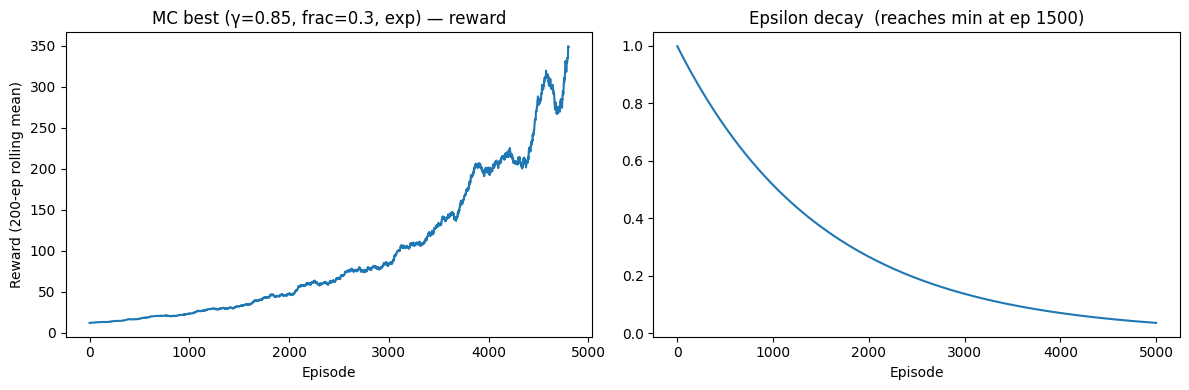

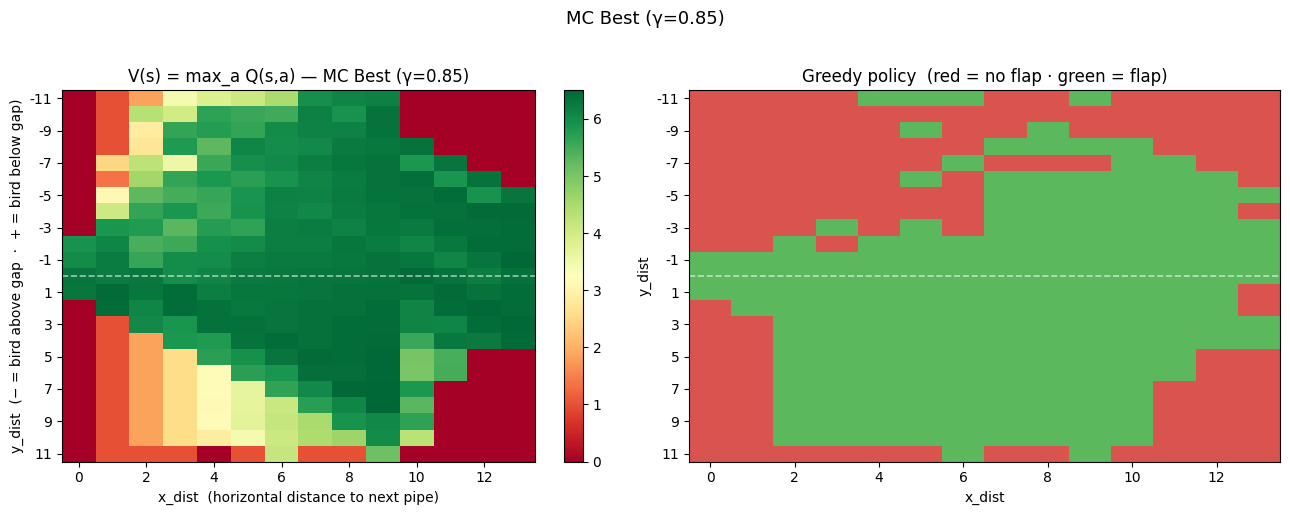

In [ ]:
### Retrain MC with best sweep hyperparameters
RETRAIN_MC_BEST = True
MC_BEST_PATH = "MC_agent_best.npy"

# Scale decay from sweep episodes to full training episodes
best_frac_mc = best_mc["explore_frac"]
retrain_decay_mc = (EPSILON_START - EPSILON_MIN) / (best_frac_mc * N_EPISODES)

print(f"Best MC config: γ={best_mc['gamma']}, explore_frac={best_frac_mc}, mode={best_mc['mode']}")
print(f"  sweep decay = {(EPSILON_START - EPSILON_MIN) / (best_frac_mc * N_SWEEP_EPISODES):.2e}")
print(f"  retrain decay (5 000 eps) = {retrain_decay_mc:.2e}")

rewards, epsilons = [], []
if RETRAIN_MC_BEST:
    agent = MCAgent(
        height=BASELINE_HEIGHT,
        width=BASELINE_WIDTH,
        pipe_gap=BASELINE_PIPE_GAP,
        gamma=best_mc["gamma"],
        epsilon=EPSILON_START,
        epsilon_min=EPSILON_MIN,
        epsilon_decay=retrain_decay_mc,
        decay_mode=best_mc["mode"],
        seed=SEED,
    )
    rewards, epsilons = train(agent, env, N_EPISODES, MAX_STEPS, LOG_EVERY)
    if SAVE_AGENT:
        agent.save(BASE_PATH / MC_BEST_PATH)
else:
    agent = MCAgent(
        height=BASELINE_HEIGHT,
        width=BASELINE_WIDTH,
        pipe_gap=BASELINE_PIPE_GAP,
        gamma=best_mc["gamma"],
        epsilon_decay=retrain_decay_mc,
        decay_mode=best_mc["mode"],
    )
    agent.load(BASE_PATH / MC_BEST_PATH)

total_rewards = evaluate(env, agent, n_episodes=100, max_steps=5000)
print(f"Best MC — Mean: {np.mean(total_rewards):.2f}  Std: {np.std(total_rewards):.2f}")

if rewards:
    window = 200
    smoothed = np.convolve(rewards, np.ones(window) / window, mode="valid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(smoothed)
    ax1.set_title(f"MC best (γ={best_mc['gamma']}, frac={best_frac_mc}, {best_mc['mode']}) — reward")
    ax1.set_xlabel("Episode")
    ax1.set_ylabel(f"Reward ({window}-ep rolling mean)")
    ax2.plot(epsilons)
    ax2.set_title(f"Epsilon decay  (reaches min at ep {int(best_frac_mc * N_EPISODES)})")
    ax2.set_xlabel("Episode")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "mc_best_training_curve.png", bbox_inches="tight")
    plt.show()

plot_value_function(
    agent,
    f"MC Best (γ={best_mc['gamma']})",
    save_path=FIGURES_DIR / "mc_best_value_function.png",
)


## 3. Sarsa(λ) Agent

**Sarsa(λ)** is an on-policy TD method that combines one-step TD with eligibility traces.
At each step the TD error is computed immediately (online), and eligibility traces
$e(s,a)$ distribute credit backwards through the trajectory.

- $\delta_t = r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t)$
- $e(s_t, a_t) \mathrel{+}= 1$
- $Q \mathrel{+}= \alpha \, \delta_t \, e$ (all state–action pairs)
- $e \mathrel{\times}= \gamma \lambda$

When $\lambda=0$ this reduces to one-step Sarsa; as $\lambda \to 1$ it approaches MC.


In [119]:
class SarsaLambdaAgent:
    def __init__(
        self,
        height: int,
        width: int,
        pipe_gap: int,
        gamma: float = 0.99,
        alpha: float = 0.1,
        lam: float = 0.9,
        epsilon: float = 1.0,
        epsilon_min: float = 0.01,
        epsilon_decay: float = 5e-4,
        decay_mode: str = "linear",
        seed: int = 42,
    ):
        self.gamma = gamma
        self.alpha = alpha
        self.lam = lam
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.decay_mode = decay_mode

        self._x_max = width - int(width * 0.3) - 1
        self._y_max = height - 1 - pipe_gap // 2 - 1
        self._y_offset = self._y_max

        self.Q = np.zeros((self._x_max + 1, 2 * self._y_max + 1, 2))
        self.E = np.zeros((self._x_max + 1, 2 * self._y_max + 1, 2))
        self._rng = np.random.default_rng(seed)

    def _idx(self, state):
        x = int(np.clip(state[0], 0, self._x_max))
        y = int(np.clip(state[1] + self._y_offset, 0, 2 * self._y_max))
        return (x, y)

    def act(self, state) -> int:
        if self._rng.random() < self.epsilon:
            return int(self._rng.integers(2))
        return int(np.argmax(self.Q[self._idx(state)]))

    def reset_traces(self) -> None:
        self.E.fill(0.0)

    def update(self, state, action, reward, next_state, next_action, done: bool) -> None:
        s_idx = self._idx(state)
        ns_idx = self._idx(next_state)
        if done:
            td_error = reward - self.Q[s_idx][action]
        else:
            td_error = reward + self.gamma * self.Q[ns_idx][next_action] - self.Q[s_idx][action]
        self.E[s_idx][action] += 1.0
        self.Q += self.alpha * td_error * self.E
        self.E *= self.gamma * self.lam

    def decay_epsilon(self) -> None:
        if self.decay_mode == "linear":
            self.epsilon = max(self.epsilon_min, self.epsilon - self.epsilon_decay)
        else:
            self.epsilon = max(self.epsilon_min, self.epsilon * (1.0 - self.epsilon_decay))

    def save(self, path: Path) -> None:
        path.parent.mkdir(parents=True, exist_ok=True)
        np.save(path, self.Q)

    def load(self, path) -> None:
        self.Q = np.load(path)


In [120]:
def run_episode_sarsa(env, agent: SarsaLambdaAgent, max_steps: int):
    state, _ = env.reset()
    action = agent.act(state)
    total_reward = 0.0
    agent.reset_traces()

    for _ in range(max_steps):
        next_state, reward, done, _, _ = env.step(action)
        next_action = agent.act(next_state)
        agent.update(state, action, reward, next_state, next_action, done)
        state, action = next_state, next_action
        total_reward += reward
        if done:
            break

    agent.decay_epsilon()
    agent.reset_traces()
    return total_reward


def train_sarsa(agent, env, episodes, max_steps, log_every):
    rewards, epsilons = [], []
    for ep in tqdm(range(episodes), desc="Training Sarsa"):
        r = run_episode_sarsa(env, agent, max_steps)
        rewards.append(r)
        epsilons.append(agent.epsilon)
        if ep > 0 and ep % log_every == 0:
            avg = np.mean(rewards[-log_every:])
            print(f"Episode {ep:>7d} | Avg reward: {avg:7.2f} | ε={agent.epsilon:.5f}")
    return rewards, epsilons


In [121]:
# Sarsa hyperparameters
SARSA_GAMMA = 0.99
SARSA_ALPHA = 0.1
SARSA_LAM = 0.9
SARSA_EPSILON_START = 1.0
SARSA_EPSILON_MIN = 0.01
SARSA_EPSILON_DECAY = 5e-4
SARSA_DECAY_MODE = "linear"

TRAIN_SARSA = True
SAVE_SARSA = True
SARSA_SAVE_PATH = "SARSA_agent.npy"
SARSA_LOAD_PATH = "SARSA_agent.npy"


In [122]:
sarsa_env = gym.make(
    "TextFlappyBird-v0",
    height=BASELINE_HEIGHT,
    width=BASELINE_WIDTH,
    pipe_gap=BASELINE_PIPE_GAP,
)

sarsa_agent = SarsaLambdaAgent(
    height=BASELINE_HEIGHT,
    width=BASELINE_WIDTH,
    pipe_gap=BASELINE_PIPE_GAP,
    gamma=SARSA_GAMMA,
    alpha=SARSA_ALPHA,
    lam=SARSA_LAM,
    epsilon=SARSA_EPSILON_START,
    epsilon_min=SARSA_EPSILON_MIN,
    epsilon_decay=SARSA_EPSILON_DECAY,
    decay_mode=SARSA_DECAY_MODE,
    seed=SEED,
)

if TRAIN_SARSA:
    sarsa_rewards, sarsa_epsilons = train_sarsa(sarsa_agent, sarsa_env, N_EPISODES, MAX_STEPS, LOG_EVERY)
    if SAVE_SARSA:
        sarsa_agent.save(BASE_PATH / SARSA_SAVE_PATH)
else:
    sarsa_agent.load(BASE_PATH / SARSA_LOAD_PATH)
    sarsa_rewards, sarsa_epsilons = [], []


Training Sarsa:  22%|██▏       | 1116/5000 [00:01<00:04, 805.42it/s]

Episode    1000 | Avg reward:   15.74 | ε=0.49950


Training Sarsa:  40%|████      | 2005/5000 [00:07<01:58, 25.37it/s] 

Episode    2000 | Avg reward:   98.50 | ε=0.01000


Training Sarsa:  60%|██████    | 3004/5000 [01:04<01:31, 21.82it/s]

Episode    3000 | Avg reward:  910.15 | ε=0.01000


Training Sarsa:  80%|████████  | 4002/5000 [01:57<01:09, 14.35it/s]

Episode    4000 | Avg reward:  869.96 | ε=0.01000


Training Sarsa: 100%|██████████| 5000/5000 [02:46<00:00, 30.04it/s]


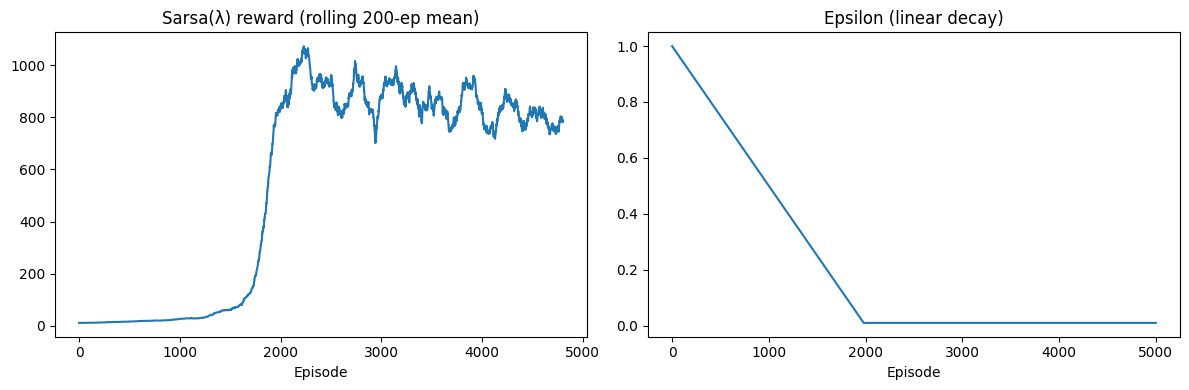

In [123]:
if sarsa_rewards:
    window = 200
    smoothed_sarsa = np.convolve(sarsa_rewards, np.ones(window) / window, mode="valid")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(smoothed_sarsa)
    ax1.set_title(f"Sarsa(λ) reward (rolling {window}-ep mean)")
    ax1.set_xlabel("Episode")
    ax2.plot(sarsa_epsilons)
    ax2.set_title(f"Epsilon ({SARSA_DECAY_MODE} decay)")
    ax2.set_xlabel("Episode")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "sarsa_training_curve.png", bbox_inches="tight")
    plt.show()


In [ ]:
sarsa_eval_rewards = evaluate(sarsa_env, sarsa_agent, n_episodes=100, max_steps=5000)
print("Sarsa(λ) greedy evaluation over 100 episodes:")
print(f"  Mean reward : {np.mean(sarsa_eval_rewards):.2f}")
print(f"  Std         : {np.std(sarsa_eval_rewards):.2f}")


Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

Sarsa(λ) greedy evaluation over 100 episodes:
  Mean reward : 5000.00
  Std         : 0.00


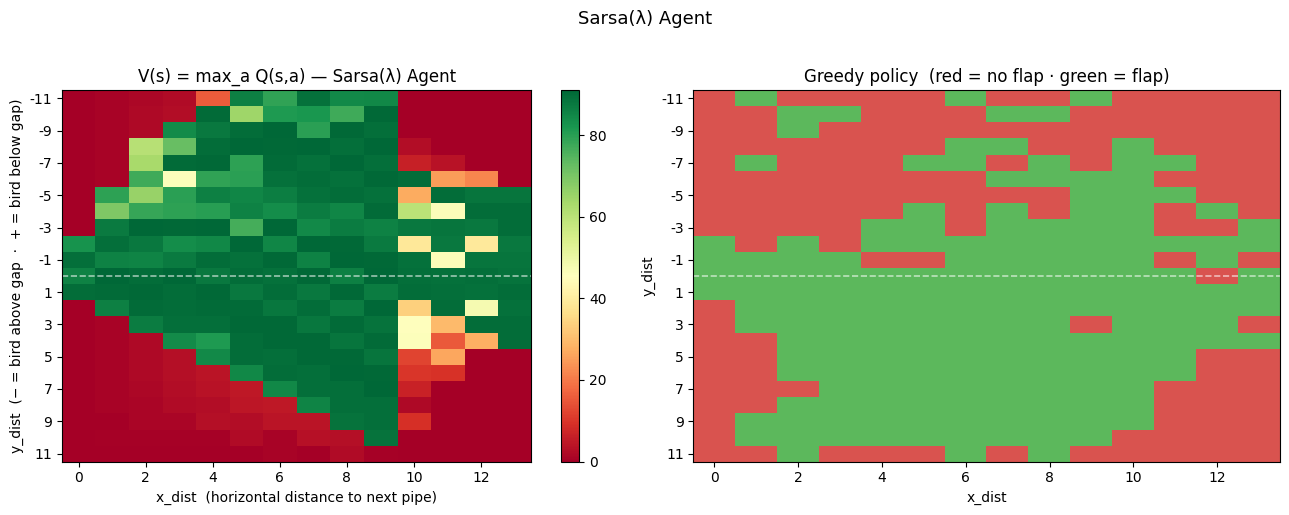

In [125]:
plot_value_function(sarsa_agent, "Sarsa(λ) Agent", save_path=FIGURES_DIR / "sarsa_value_function.png")

### Sarsa(λ) Hyperparameter Grid Search


In [ ]:
RETRAIN_SARSA_SWEEP = True
SARSA_SWEEP_PATH = BASE_PATH / "sarsa_sweep_results.pkl"

_s_alphas = [0.05, 0.1, 0.2]
_s_lambdas = [0.7, 0.9, 0.95]
_s_explore_fracs = [0.3, 0.6, 0.9]

if RETRAIN_SARSA_SWEEP or not SARSA_SWEEP_PATH.exists():
    sweep_env2 = gym.make(
        "TextFlappyBird-v0",
        height=BASELINE_HEIGHT,
        width=BASELINE_WIDTH,
        pipe_gap=BASELINE_PIPE_GAP,
    )
    sarsa_sweep_results = []

    combos = list(itertools.product(_s_alphas, _s_lambdas, _s_explore_fracs))
    for alpha, lam, frac in tqdm(combos, desc="Sarsa sweep"):
        sweep_decay = (SARSA_EPSILON_START - SARSA_EPSILON_MIN) / (frac * N_SWEEP_EPISODES)
        ag = SarsaLambdaAgent(
            height=BASELINE_HEIGHT,
            width=BASELINE_WIDTH,
            pipe_gap=BASELINE_PIPE_GAP,
            gamma=SARSA_GAMMA,
            alpha=alpha,
            lam=lam,
            epsilon=SARSA_EPSILON_START,
            epsilon_min=SARSA_EPSILON_MIN,
            epsilon_decay=sweep_decay,
            decay_mode=SARSA_DECAY_MODE,
            seed=SEED,
        )
        curve, _ = train_sarsa(ag, sweep_env2, N_SWEEP_EPISODES, MAX_STEPS, log_every=N_SWEEP_EPISODES + 1)
        eval_rewards = evaluate(sweep_env2, ag, N_SWEEP_EVAL, MAX_STEPS)
        sarsa_sweep_results.append(
            {
                "alpha": alpha,
                "lam": lam,
                "explore_frac": frac,
                "mean_eval": float(np.mean(eval_rewards)),
                "curve": curve,
            },
        )

    sweep_env2.close()
    SARSA_SWEEP_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(SARSA_SWEEP_PATH, "wb") as f:
        pickle.dump(sarsa_sweep_results, f)
    print(f"Saved Sarsa sweep results to {SARSA_SWEEP_PATH}")
else:
    with open(SARSA_SWEEP_PATH, "rb") as f:
        sarsa_sweep_results = pickle.load(f)
    print(f"Loaded Sarsa sweep results from {SARSA_SWEEP_PATH}")

best_sarsa = max(sarsa_sweep_results, key=lambda x: x["mean_eval"])
print(
    f"\nBest Sarsa config: alpha={best_sarsa['alpha']}, λ={best_sarsa['lam']}, "
    f"explore_frac={best_sarsa['explore_frac']}:  mean_eval={best_sarsa['mean_eval']:.2f}",
)


Sarsa sweep: 100%|██████████| 27/27 [04:47<00:00, 10.66s/it]

Saved Sarsa sweep results to ../models/sarsa_sweep_results.pkl

Best Sarsa config: alpha=0.1, λ=0.7, explore_frac=0.9  →  mean_eval=3000.00


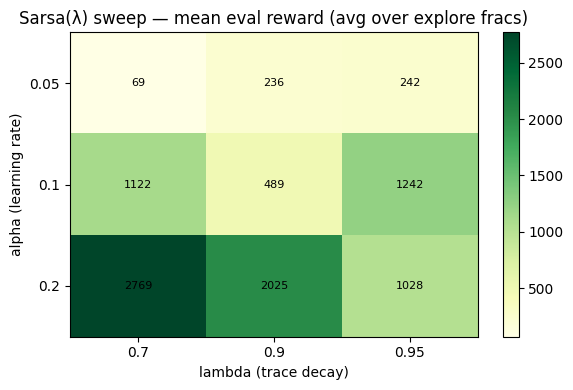

MC   best mean eval : 3000.00  (γ=0.85, explore_frac=0.3, mode=exp)
Sarsa best mean eval: 3000.00  (α=0.1, λ=0.7, explore_frac=0.9)


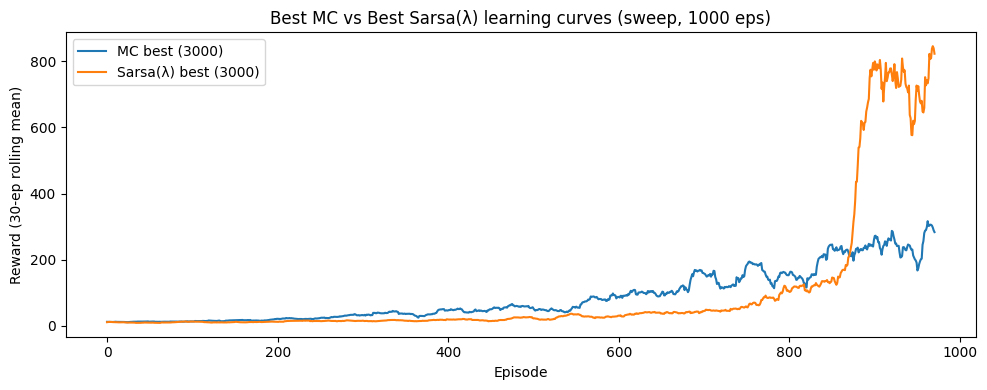

In [ ]:
# Heatmap: alpha × lambda (averaged over explore_fracs)
data_al = np.zeros((len(_s_alphas), len(_s_lambdas)))
for r in sarsa_sweep_results:
    i = _s_alphas.index(r["alpha"])
    j = _s_lambdas.index(r["lam"])
    data_al[i, j] += r["mean_eval"] / len(_s_explore_fracs)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(data_al, cmap="YlGn", aspect="auto")
ax.set_xticks(range(len(_s_lambdas)))
ax.set_xticklabels(_s_lambdas)
ax.set_yticks(range(len(_s_alphas)))
ax.set_yticklabels(_s_alphas)
ax.set_xlabel("lambda (trace decay)")
ax.set_ylabel("alpha (learning rate)")
ax.set_title("Sarsa(λ) sweep  mean eval reward (avg over explore fracs)")
plt.colorbar(im, ax=ax)
for i, j in itertools.product(range(len(_s_alphas)), range(len(_s_lambdas))):
    ax.text(j, i, f"{data_al[i, j]:.0f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "sarsa_sweep_heatmap.png", bbox_inches="tight")
plt.show()

# Best configs comparison: MC best vs Sarsa best
print(
    f"MC   best mean eval : {best_mc['mean_eval']:.2f}  "
    f"(γ={best_mc['gamma']}, explore_frac={best_mc['explore_frac']}, mode={best_mc['mode']})",
)
print(
    f"Sarsa best mean eval: {best_sarsa['mean_eval']:.2f}  "
    f"(α={best_sarsa['alpha']}, λ={best_sarsa['lam']}, explore_frac={best_sarsa['explore_frac']})",
)

# Learning curve comparison for best of each
fig, ax = plt.subplots(figsize=(10, 4))
window = 30
mc_c = np.convolve(best_mc["curve"], np.ones(window) / window, mode="valid")
sarsa_c = np.convolve(best_sarsa["curve"], np.ones(window) / window, mode="valid")
ax.plot(mc_c, label=f"MC best ({best_mc['mean_eval']:.0f})")
ax.plot(sarsa_c, label=f"Sarsa(λ) best ({best_sarsa['mean_eval']:.0f})")
ax.set_xlabel("Episode")
ax.set_ylabel(f"Reward ({window}-ep rolling mean)")
ax.set_title("Best MC vs Best Sarsa(λ) learning curves (sweep, 1000 eps)")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "sarsa_best_vs_mc_best.png", bbox_inches="tight")
plt.show()


Best Sarsa config: α=0.1, λ=0.7, explore_frac=0.9
  sweep decay = 1.10e-03
  retrain decay (5 000 eps) = 2.20e-04


Training Sarsa:   0%|          | 0/5000 [00:00<?, ?it/s]

Training Sarsa:  24%|██▍       | 1223/5000 [00:00<00:03, 1243.33it/s]

Episode    1000 | Avg reward:   12.91 | ε=0.77978


Training Sarsa:  42%|████▏     | 2080/5000 [00:01<00:03, 839.72it/s] 

...

Episode    3000 | Avg reward:   27.19 | ε=0.33978


Training Sarsa:  80%|████████  | 4012/5000 [00:07<00:06, 153.25it/s]

Episode    4000 | Avg reward:   57.24 | ε=0.11978


Training Sarsa: 100%|██████████| 5000/5000 [00:46<00:00, 107.10it/s]


Best Sarsa — Mean: 5000.00  Std: 0.00


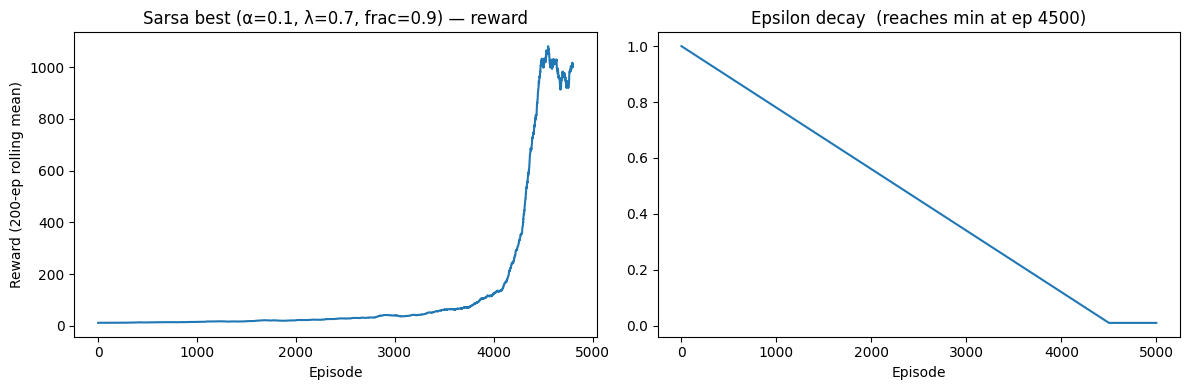

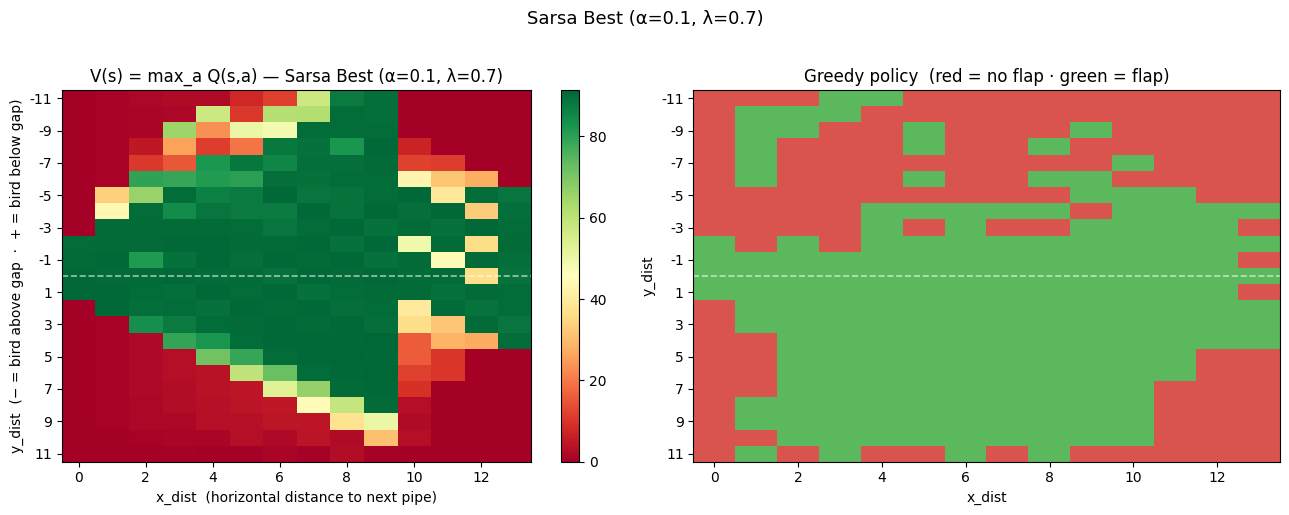

In [ ]:
RETRAIN_SARSA_BEST = True
SARSA_BEST_PATH = "SARSA_agent_best.npy"

best_frac = best_sarsa["explore_frac"]
retrain_decay = (SARSA_EPSILON_START - SARSA_EPSILON_MIN) / (best_frac * N_EPISODES)

print(f"Best Sarsa config: α={best_sarsa['alpha']}, λ={best_sarsa['lam']}, explore_frac={best_frac}")
print(f"  sweep decay = {(SARSA_EPSILON_START - SARSA_EPSILON_MIN) / (best_frac * N_SWEEP_EPISODES):.2e}")
print(f"  retrain decay (5 000 eps) = {retrain_decay:.2e}")

sarsa_rewards, sarsa_epsilons = [], []
if RETRAIN_SARSA_BEST:
    sarsa_agent = SarsaLambdaAgent(
        height=BASELINE_HEIGHT,
        width=BASELINE_WIDTH,
        pipe_gap=BASELINE_PIPE_GAP,
        gamma=SARSA_GAMMA,
        alpha=best_sarsa["alpha"],
        lam=best_sarsa["lam"],
        epsilon=SARSA_EPSILON_START,
        epsilon_min=SARSA_EPSILON_MIN,
        epsilon_decay=retrain_decay,
        decay_mode=SARSA_DECAY_MODE,
        seed=SEED,
    )
    sarsa_rewards, sarsa_epsilons = train_sarsa(sarsa_agent, sarsa_env, N_EPISODES, MAX_STEPS, LOG_EVERY)
    if SAVE_SARSA:
        sarsa_agent.save(BASE_PATH / SARSA_BEST_PATH)
else:
    sarsa_agent = SarsaLambdaAgent(
        height=BASELINE_HEIGHT,
        width=BASELINE_WIDTH,
        pipe_gap=BASELINE_PIPE_GAP,
        gamma=SARSA_GAMMA,
        alpha=best_sarsa["alpha"],
        lam=best_sarsa["lam"],
        epsilon_decay=retrain_decay,
    )
    sarsa_agent.load(BASE_PATH / SARSA_BEST_PATH)

sarsa_eval_rewards = evaluate(sarsa_env, sarsa_agent, n_episodes=100, max_steps=5000)
print(f"Best Sarsa — Mean: {np.mean(sarsa_eval_rewards):.2f}  Std: {np.std(sarsa_eval_rewards):.2f}")

window = 200
smoothed_sarsa = np.convolve(sarsa_rewards, np.ones(window) / window, mode="valid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(smoothed_sarsa)
ax1.set_title(f"Sarsa best (α={best_sarsa['alpha']}, λ={best_sarsa['lam']}, frac={best_frac}) — reward")
ax1.set_xlabel("Episode")
ax1.set_ylabel(f"Reward ({window}-ep rolling mean)")
ax2.plot(sarsa_epsilons)
ax2.set_title(f"Epsilon decay  (reaches min at ep {int(best_frac * N_EPISODES)})")
ax2.set_xlabel("Episode")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "sarsa_best_training_curve.png", bbox_inches="tight")
plt.show()

plot_value_function(
    sarsa_agent,
    f"Sarsa Best (α={best_sarsa['alpha']}, λ={best_sarsa['lam']})",
    save_path=FIGURES_DIR / "sarsa_best_value_function.png",
)


### Best MC vs Best Sarsa(λ) — Comparison

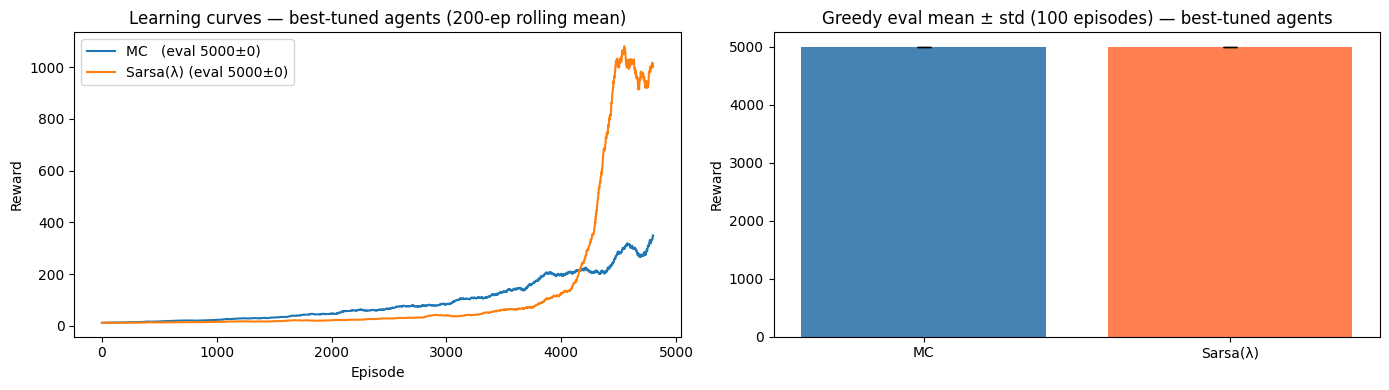

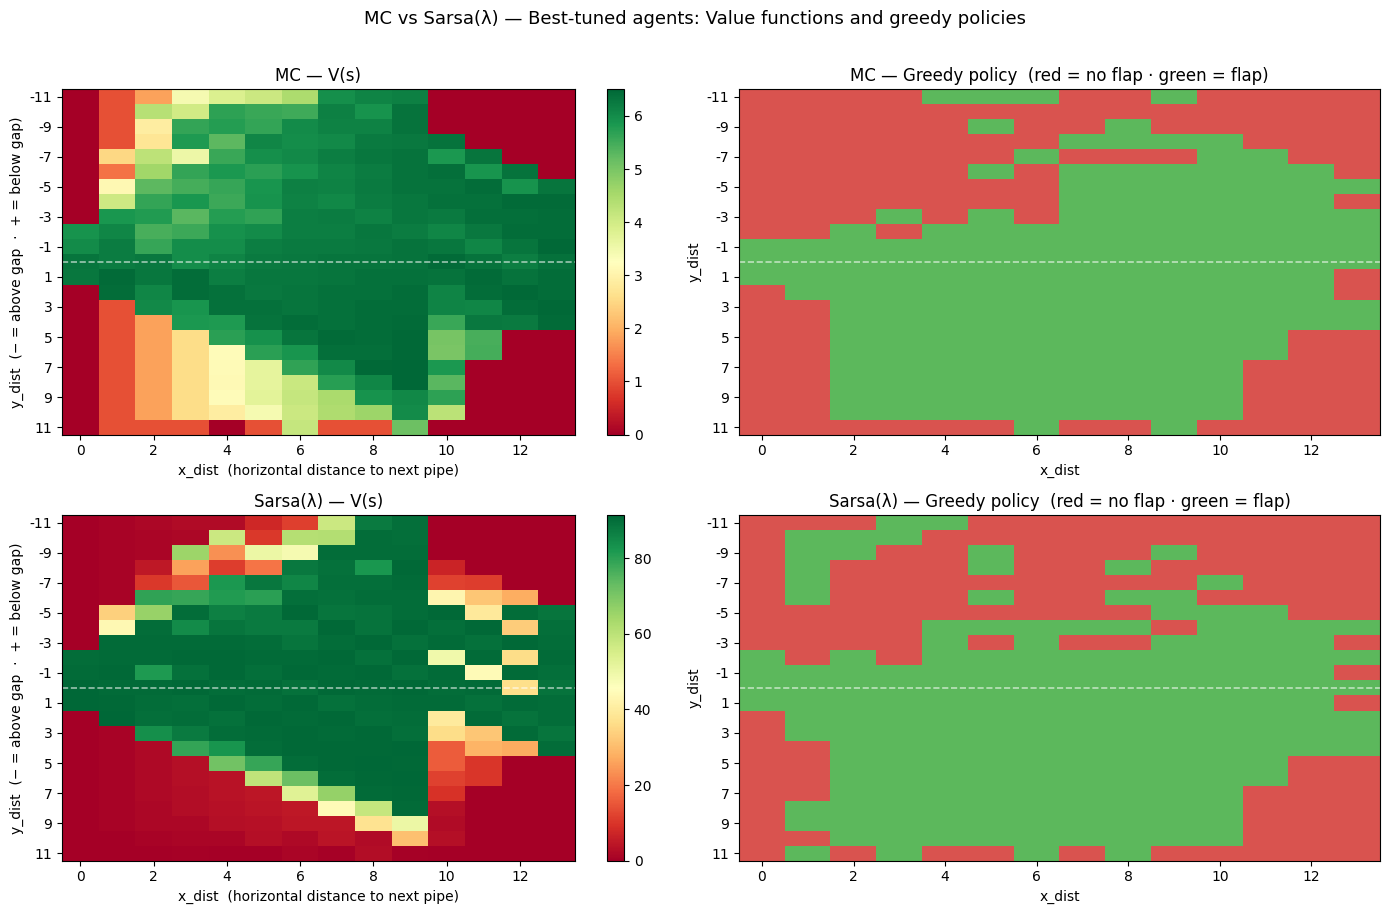

In [ ]:
# Side-by-side learning curves — best-tuned agents
if sarsa_rewards and rewards:
    window = 200
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sm_mc = np.convolve(rewards, np.ones(window) / window, mode="valid")
    sm_sarsa = np.convolve(sarsa_rewards, np.ones(window) / window, mode="valid")

    axes[0].plot(sm_mc, label=f"MC   (eval {np.mean(total_rewards):.0f}±{np.std(total_rewards):.0f})")
    axes[0].plot(
        sm_sarsa,
        label=f"Sarsa(λ) (eval {np.mean(sarsa_eval_rewards):.0f}±{np.std(sarsa_eval_rewards):.0f})",
    )
    axes[0].set_title(f"Learning curves — best-tuned agents ({window}-ep rolling mean)")
    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Reward")
    axes[0].legend()

    axes[1].bar(
        ["MC", "Sarsa(λ)"],
        [np.mean(total_rewards), np.mean(sarsa_eval_rewards)],
        yerr=[np.std(total_rewards), np.std(sarsa_eval_rewards)],
        capsize=5,
        color=["steelblue", "coral"],
    )
    axes[1].set_title("Greedy eval mean ± std (100 episodes) — best-tuned agents")
    axes[1].set_ylabel("Reward")

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "mc_sarsa_learning_curves.png", bbox_inches="tight")
    plt.show()

# Side-by-side V(s) heatmaps — best-tuned agents
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (ag, name) in enumerate([(agent, "MC"), (sarsa_agent, "Sarsa(λ)")]):
    Q = ag.Q
    V = np.max(Q, axis=2)
    policy = np.argmax(Q, axis=2)
    y_max = ag._y_max

    im = axes[row, 0].imshow(V.T, cmap="RdYlGn", aspect="auto", origin="upper")
    axes[row, 0].set_title(f"{name} — V(s)")
    axes[row, 0].set_xlabel("x_dist  (horizontal distance to next pipe)")
    step = max(1, y_max // 4)
    ytick_idx = np.arange(0, 2 * y_max + 1, step)
    axes[row, 0].set_yticks(ytick_idx)
    axes[row, 0].set_yticklabels(ytick_idx - y_max)
    axes[row, 0].set_ylabel("y_dist  (− = above gap  ·  + = below gap)")
    axes[row, 0].axhline(y_max, color="white", linewidth=1.2, linestyle="--", alpha=0.6)
    plt.colorbar(im, ax=axes[row, 0])

    cmap2 = mcolors.ListedColormap(["#d9534f", "#5cb85c"])
    axes[row, 1].imshow(policy.T, cmap=cmap2, aspect="auto", origin="upper", vmin=0, vmax=1)
    axes[row, 1].set_title(f"{name} — Greedy policy  (red = no flap · green = flap)")
    axes[row, 1].set_xlabel("x_dist")
    axes[row, 1].set_yticks(ytick_idx)
    axes[row, 1].set_yticklabels(ytick_idx - y_max)
    axes[row, 1].set_ylabel("y_dist")
    axes[row, 1].axhline(y_max, color="white", linewidth=1.2, linestyle="--", alpha=0.6)

plt.suptitle("MC vs Sarsa(λ) — Best-tuned agents: Value functions and greedy policies", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "mc_sarsa_value_functions.png", bbox_inches="tight")
plt.show()


## 4. Adaptability of the Agents

We evaluate how well a policy trained on the **baseline configuration**
(height=15, width=20, pipe\_gap=4) transfers to environments with different parameters.

Because the Q-table is indexed by `(x_dist, y_dist + y_offset)`, states outside the trained
range are **clipped** to the nearest valid index — this simulates zero-shot transfer
with a slightly aggressive assumption.

Three axes of variation are tested:
- **pipe\_gap**: controls difficulty (smaller gap → harder)
- **height**: changes the vertical state space
- **width**: changes the horizontal state space


In [ ]:
RETRAIN_BENCHMARK = True
BENCHMARK_PATH = BASE_PATH / "benchmark_results.pkl"

N_BENCH_EVAL = 100


def evaluate_transfer(agent, env_height, env_width, env_pipe_gap, n_episodes, max_steps):
    env = gym.make("TextFlappyBird-v0", height=env_height, width=env_width, pipe_gap=env_pipe_gap)

    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        total_r = 0.0
        done = False
        steps = 0
        while not done and steps < max_steps:
            idx = agent._idx(obs)  # uses trained agent's x_max, y_max, y_offset
            action = int(np.argmax(agent.Q[idx]))
            obs, r, done, _, _ = env.step(action)
            total_r += r
            steps += 1
        rewards.append(total_r)
    env.close()
    return rewards


if RETRAIN_BENCHMARK or not BENCHMARK_PATH.exists():
    bench_results = {}

    # --- pipe_gap sensitivity ---
    pipe_gaps = [2, 3, 4, 5, 6]
    bench_results["pipe_gap"] = {"values": pipe_gaps, "mc": [], "sarsa": [], "mc_std": [], "sarsa_std": []}
    for gap in tqdm(pipe_gaps, desc="pipe_gap sweep"):
        mc_r = evaluate_transfer(agent, BASELINE_HEIGHT, BASELINE_WIDTH, gap, N_BENCH_EVAL, MAX_STEPS)
        sarsa_r = evaluate_transfer(
            sarsa_agent,
            BASELINE_HEIGHT,
            BASELINE_WIDTH,
            gap,
            N_BENCH_EVAL,
            MAX_STEPS,
        )
        bench_results["pipe_gap"]["mc"].append(float(np.mean(mc_r)))
        bench_results["pipe_gap"]["mc_std"].append(float(np.std(mc_r)))
        bench_results["pipe_gap"]["sarsa"].append(float(np.mean(sarsa_r)))
        bench_results["pipe_gap"]["sarsa_std"].append(float(np.std(sarsa_r)))

    # --- height sensitivity --
    heights = [10, 12, 15, 18, 20]
    bench_results["height"] = {"values": heights, "mc": [], "sarsa": [], "mc_std": [], "sarsa_std": []}
    for h in tqdm(heights, desc="height sweep"):
        mc_r = evaluate_transfer(agent, h, BASELINE_WIDTH, BASELINE_PIPE_GAP, N_BENCH_EVAL, MAX_STEPS)
        sarsa_r = evaluate_transfer(
            sarsa_agent,
            h,
            BASELINE_WIDTH,
            BASELINE_PIPE_GAP,
            N_BENCH_EVAL,
            MAX_STEPS,
        )
        bench_results["height"]["mc"].append(float(np.mean(mc_r)))
        bench_results["height"]["mc_std"].append(float(np.std(mc_r)))
        bench_results["height"]["sarsa"].append(float(np.mean(sarsa_r)))
        bench_results["height"]["sarsa_std"].append(float(np.std(sarsa_r)))

    # --- width sensitivity --
    widths = [12, 15, 20, 25, 30]
    bench_results["width"] = {"values": widths, "mc": [], "sarsa": [], "mc_std": [], "sarsa_std": []}
    for w in tqdm(widths, desc="width sweep"):
        mc_r = evaluate_transfer(agent, BASELINE_HEIGHT, w, BASELINE_PIPE_GAP, N_BENCH_EVAL, MAX_STEPS)
        sarsa_r = evaluate_transfer(
            sarsa_agent,
            BASELINE_HEIGHT,
            w,
            BASELINE_PIPE_GAP,
            N_BENCH_EVAL,
            MAX_STEPS,
        )
        bench_results["width"]["mc"].append(float(np.mean(mc_r)))
        bench_results["width"]["mc_std"].append(float(np.std(mc_r)))
        bench_results["width"]["sarsa"].append(float(np.mean(sarsa_r)))
        bench_results["width"]["sarsa_std"].append(float(np.std(sarsa_r)))

    BENCHMARK_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(BENCHMARK_PATH, "wb") as f:
        pickle.dump(bench_results, f)
    print(f"Saved benchmark results to {BENCHMARK_PATH}")
else:
    with open(BENCHMARK_PATH, "rb") as f:
        bench_results = pickle.load(f)
    print(f"Loaded benchmark results from {BENCHMARK_PATH}")


pipe_gap sweep:   0%|          | 0/5 [00:00<?, ?it/s]

width sweep: 100%|██████████| 5/5 [00:32<00:00,  6.49s/it]

Saved benchmark results to ../models/benchmark_results.pkl


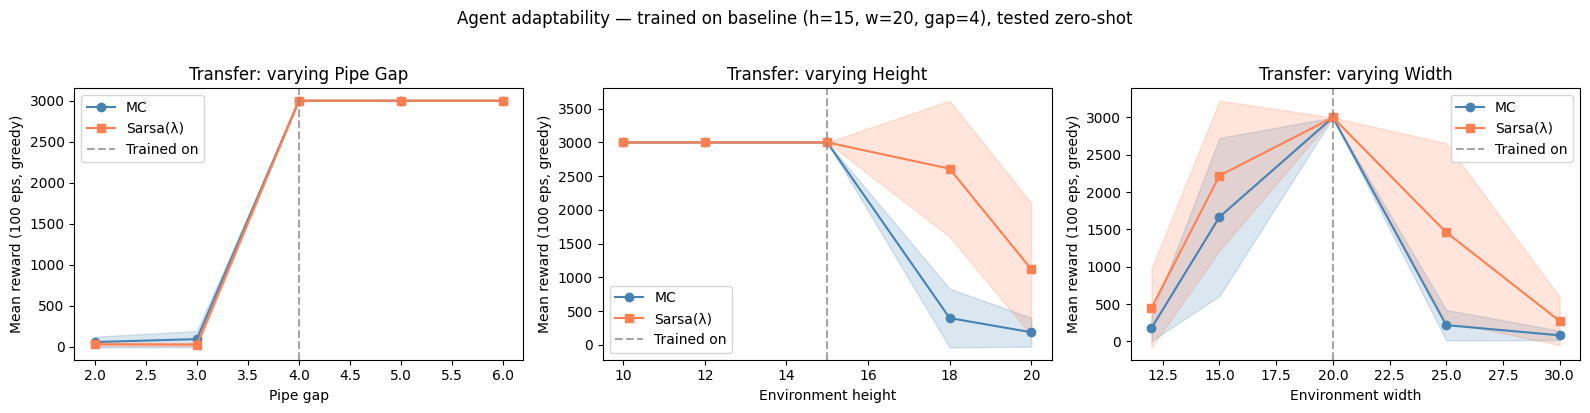

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

param_map = {
    "pipe_gap": ("Pipe Gap", "Pipe gap"),
    "height": ("Height", "Environment height"),
    "width": ("Width", "Environment width"),
}

for ax, (key, (short, label)) in zip(axes, param_map.items()):
    vals = bench_results[key]["values"]
    mc_r = np.array(bench_results[key]["mc"])
    sarsa_r = np.array(bench_results[key]["sarsa"])
    mc_std = np.array(bench_results[key].get("mc_std", np.zeros_like(mc_r)))
    sarsa_std = np.array(bench_results[key].get("sarsa_std", np.zeros_like(sarsa_r)))

    ax.plot(vals, mc_r, "o-", color="steelblue", label="MC")
    ax.fill_between(vals, mc_r - mc_std, mc_r + mc_std, alpha=0.2, color="steelblue")

    ax.plot(vals, sarsa_r, "s-", color="coral", label="Sarsa(λ)")
    ax.fill_between(vals, sarsa_r - sarsa_std, sarsa_r + sarsa_std, alpha=0.2, color="coral")

    if key == "height":
        ax.axvline(BASELINE_HEIGHT, color="gray", linestyle="--", alpha=0.7, label="Trained on")
    elif key == "width":
        ax.axvline(BASELINE_WIDTH, color="gray", linestyle="--", alpha=0.7, label="Trained on")
    elif key == "pipe_gap":
        ax.axvline(BASELINE_PIPE_GAP, color="gray", linestyle="--", alpha=0.7, label="Trained on")

    ax.set_xlabel(label)
    ax.set_ylabel("Mean reward (100 eps, greedy)")
    ax.set_title(f"Transfer: varying {short}")
    ax.legend()

plt.suptitle(
    "Agent adaptability - trained on baseline (h=15, w=20, gap=4), tested zero-shot",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "adaptability.png", bbox_inches="tight")
plt.show()
